# Bandit benchmark notebook

Этот ноутбук запускает benchmark-пайплайн (аналогично `src/run_benchmark.py`) на вашем датасете.

## 1) Настройки

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import pandas as pd
import polars as pl

ROOT = Path.cwd().resolve().parent if Path.cwd().name == 'notebooks' else Path.cwd().resolve()
SRC = ROOT / 'src'
if str(SRC) not in sys.path:
    sys.path.insert(0, str(SRC))

from run_benchmark import load_dataset
from bandit_benchmark import (
    CatBoostPolicy,
    LogisticTSLibPolicy,
    LaplaceThompsonViaBayesianLogRegPolicy,
    NeuralLaplaceThompsonViaBayesianLogRegPolicy,
    PartitionedTSLibPolicy,
    RandomPolicy,
    EpsilonGreedyPolicy,
    UCBPolicy,
    ThompsonSamplingPolicy,
    build_expected_reward_estimator,
    core_scenarios,
    default_five_scenarios,
    make_simulated_environment,
    preprocess_bandit_dataframe,
    run_scenarios,
    split_train_test_by_date,
)
from prepare_datasets import stage1_make_splits, stage2_scale_features


In [4]:
# Укажите путь к данным (.tsv или .parquet)
DATA_PATH = ROOT / 'data' / 'events.tsv'
PREPARED_TRAIN_PATH = ROOT / 'artifacts' / 'datasets' / 'train_variant_1_scaled.parquet'
PREPARED_TEST_PATH = ROOT / 'artifacts' / 'datasets' / 'test_variant_1_scaled.parquet'
USE_PREPARED_SPLITS = True
TEST_RATIO = 0.5
EPSILON = 0.1
SEED = 42
SIMULATE = False
STOCHASTIC_SIM = True
FULL_SCENARIOS = False

USE_SAMPLED_DATASET = False
SAMPLE_FRACTION = 0.2  # доля строк для train/test при демо-прогоне


## 2) Загрузка и препроцессинг

In [5]:
if USE_PREPARED_SPLITS and PREPARED_TRAIN_PATH.exists() and PREPARED_TEST_PATH.exists():
    train_df = pl.read_parquet(PREPARED_TRAIN_PATH)
    test_df = pl.read_parquet(PREPARED_TEST_PATH)
    print('loaded prepared splits')
else:
    # Stage 1: load -> split -> filter -> save
    train_s1, test_s1 = stage1_make_splits(str(DATA_PATH), str(ROOT / 'artifacts' / 'datasets'), TEST_RATIO, SEED)
    # Stage 2: scale features and save prepared datasets
    train_final, test_final = stage2_scale_features(train_s1, test_s1, str(ROOT / 'artifacts' / 'datasets'))
    train_df = pl.read_parquet(train_final)
    test_df = pl.read_parquet(test_final)

print('train:', train_df.height, 'test(random only):', test_df.height)


loaded prepared splits
train: 12701839 test(random only): 3925311


## 3) Конфиг политик и сценариев

In [6]:
policy_factories = {
    'random': lambda: RandomPolicy(seed=SEED),
    'epsilon_greedy': lambda: EpsilonGreedyPolicy(epsilon=EPSILON, seed=SEED),
    'ucb': lambda: UCBPolicy(),
    'thompson_sampling': lambda: ThompsonSamplingPolicy(seed=SEED),
}

try:
    import scipy  # noqa: F401
    policy_factories['laplace_ts_logreg'] = lambda: LaplaceThompsonViaBayesianLogRegPolicy(seed=SEED)
    try:
        import torch  # noqa: F401
        policy_factories['neural_laplace_ts_logreg'] = lambda: NeuralLaplaceThompsonViaBayesianLogRegPolicy(seed=SEED)
    except Exception:
        print('torch is unavailable: skipping NeuralLaplaceThompsonViaBayesianLogRegPolicy')
except Exception:
    print('scipy is unavailable: skipping LaplaceThompsonViaBayesianLogRegPolicy')

try:
    import catboost  # noqa: F401
    policy_factories['catboost'] = lambda: CatBoostPolicy(random_seed=SEED)
except Exception:
    print('catboost is unavailable: skipping CatBoostPolicy')

# try:
#     import contextualbandits  # noqa: F401
#     policy_factories['logistic_ts'] = lambda: LogisticTSLibPolicy(random_seed=SEED)
#     policy_factories['partitioned_ts'] = lambda: PartitionedTSLibPolicy(random_seed=SEED)
# except Exception:
#     print('contextualbandits is unavailable: skipping LogisticTS/PartitionedTS')

scenarios = default_five_scenarios() if FULL_SCENARIOS else core_scenarios()

## 4) Запуск benchmark

## 4.1) Опциональный сэмпл для быстрого прогона


In [7]:
if USE_SAMPLED_DATASET:
    if not (0.0 < SAMPLE_FRACTION <= 1.0):
        raise ValueError('SAMPLE_FRACTION must be in (0, 1]')
    train_eval_df = train_df.sample(fraction=SAMPLE_FRACTION, shuffle=True, seed=SEED).sort('date')
    test_eval_df = test_df.sample(fraction=SAMPLE_FRACTION, shuffle=True, seed=SEED).sort('date')
else:
    train_eval_df = train_df
    test_eval_df = test_df

print('eval train rows:', train_eval_df.height, 'of', train_df.height)
print('eval test rows:', test_eval_df.height, 'of', test_df.height)


eval train rows: 12701839 of 12701839
eval test rows: 3925311 of 3925311


In [8]:
env_reward = None
if SIMULATE:
    expected_fn = build_expected_reward_estimator(train_df)
    env_reward = make_simulated_environment(
        proba_predictor=expected_fn,
        stochastic=STOCHASTIC_SIM,
        seed=SEED,
    )

result = run_scenarios(
    train_df=train_eval_df,
    test_df=test_eval_df,
    policy_factories=policy_factories,
    scenarios=scenarios,
    env_reward=env_reward,
    show_progress=True,
)

metrics_df = result['metrics']
history_df = result['history']
action_stats_df = result['action_stats']
action_daily_stats_df = result['action_daily_stats']

display(metrics_df)

sensitive_cols = ['scenario', 'algo', 'sensitive_impressions', 'ips_ctr_sensitive', 'ips_regret_sens']
if set(sensitive_cols).issubset(metrics_df.columns):
    print('sensitive IPS metrics (rows with len(candidates) > 1):')
    display(metrics_df[sensitive_cols].sort_values(['scenario', 'algo']).reset_index(drop=True))

print('history rows:', len(history_df))
if SIMULATE:
    display(action_stats_df)
    display(action_daily_stats_df)


case_2_random_pretrain_online_update/random:   0%|  | 0/3925311 [00:00<?, ?it/s]

case_2_random_pretrain_online_update/random: train_unique_actions=50


case_2_random_pretrain_online_update/epsilon_greedy:   0%| | 0/3925311 [00:00<?,

case_2_random_pretrain_online_update/epsilon_greedy: train_unique_actions=50


case_2_random_pretrain_online_update/ucb:   0%|     | 0/3925311 [00:00<?, ?it/s]

...

case_2_random_pretrain_online_update/catboost: train_unique_actions=50


,impressions_total,impressions_used,total_reward,ctr,ips_weighted_reward,ips_ctr,replay_match_rate,cumulative_regret,avg_regret,cumulative_ips_regret,avg_ips_regret,sensitive_impressions,ips_ctr_sensitive,ips_regret_sens,scenario,algo
0,3925311,2764431,47129.0,0.017048,67938.0,0.017308,0.704258,10208.645841,0.003693,50052.722959,0.012751,2003029,0.017491,0.025617,case_2_random_pretrain_online_update,random
1,3925311,2761985,56418.0,0.020427,93585.0,0.023841,0.703635,1436.451915,0.000520,40763.722959,0.010385,2003029,0.030295,0.020980,case_2_random_pretrain_online_update,epsilon_greedy
2,3925311,2774748,57266.0,0.020638,95224.0,0.024259,0.706886,746.912702,0.000269,39915.722959,0.010169,2003029,0.031113,0.020556,case_2_random_pretrain_online_update,ucb
3,3925311,2766436,57761.0,0.020879,97026.0,0.024718,0.704769,204.326288,0.000074,39420.722959,0.010043,2003029,0.032013,0.020309,case_2_random_pretrain_online_update,thompson_sampling
4,3925311,2758678,55888.0,0.020259,90688.0,0.023103,0.702792,1572.489506,0.000570,41293.722959,0.010520,2003029,0.028848,0.021244,case_2_random_pretrain_online_update,laplace_ts_logreg
5,3925311,2766649,57918.0,0.020934,97358.0,0.024803,0.704823,35.146080,0.000013,39263.722959,0.010003,2003029,0.032178,0.020231,case_2_random_pretrain_online_update,neural_laplace_ts_logreg
6,3925311,2761882,55430.0,0.020070,89966.0,0.022919,0.703608,2382.068062,0.000862,41751.722959,0.010637,2003029,0.028488,0.021473,case_2_random_pretrain_online_update,catboost


sensitive IPS metrics (rows with len(candidates) > 1):


,scenario,algo,sensitive_impressions,ips_ctr_sensitive,ips_regret_sens
0,case_2_random_pretrain_online_update,catboost,2003029,0.028488,0.021473
1,case_2_random_pretrain_online_update,epsilon_greedy,2003029,0.030295,0.020980
2,case_2_random_pretrain_online_update,laplace_ts_logreg,2003029,0.028848,0.021244
3,case_2_random_pretrain_online_update,neural_laplace_ts_logreg,2003029,0.032178,0.020231
4,case_2_random_pretrain_online_update,random,2003029,0.017491,0.025617
5,case_2_random_pretrain_online_update,thompson_sampling,2003029,0.032013,0.020309
6,case_2_random_pretrain_online_update,ucb,2003029,0.031113,0.020556


history rows: 19354809


In [19]:
metrics_df[["algo", "ips_ctr_sensitive"]].sort_values(by="ips_ctr_sensitive", ascending=False)

,algo,ips_ctr_sensitive
5,neural_laplace_ts_logreg,0.032178
3,thompson_sampling,0.032013
2,ucb,0.031113
1,epsilon_greedy,0.030295
4,laplace_ts_logreg,0.028848
6,catboost,0.028488
0,random,0.017491


## 5) Графики по сценариям

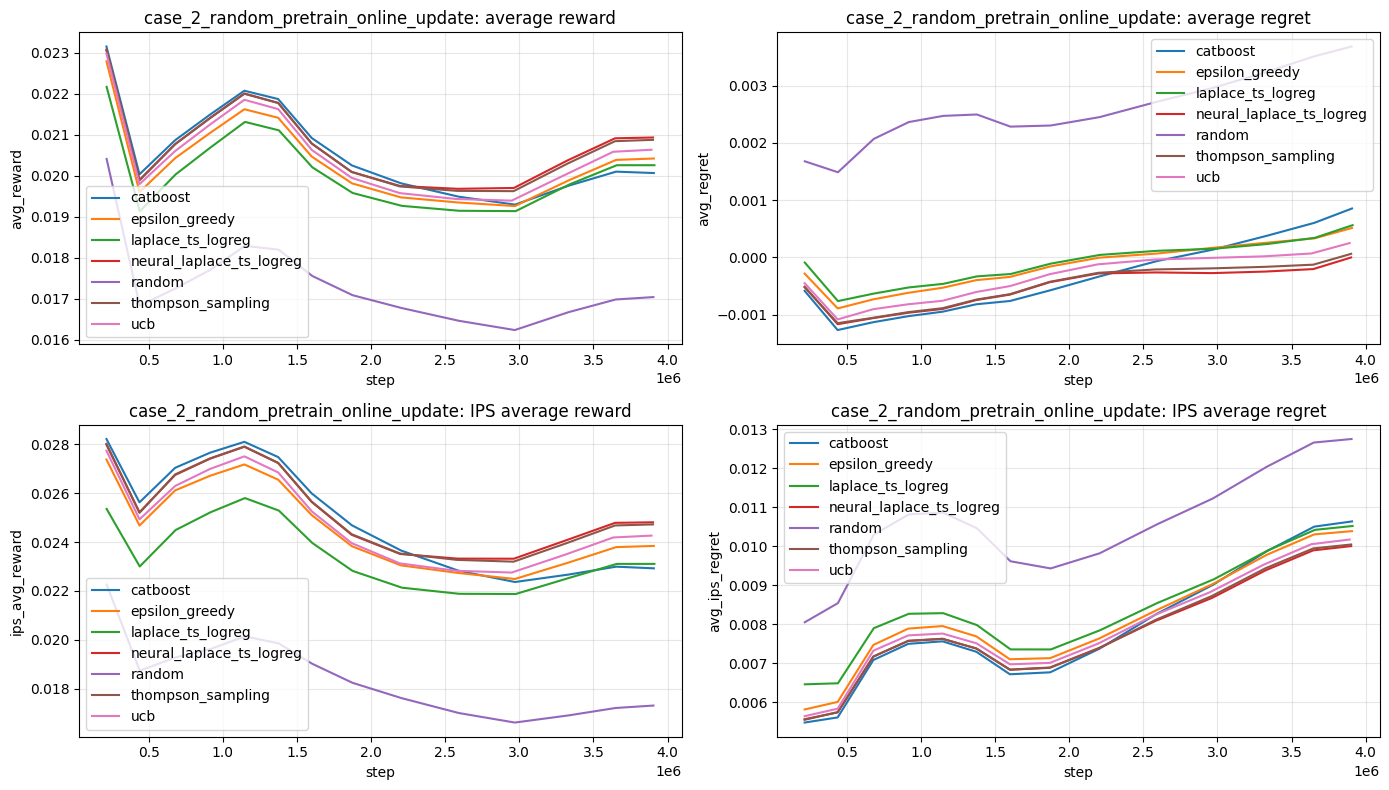

In [9]:
if not history_df.empty:
    for scenario_name, part in history_df.groupby('scenario'):
        fig, axes = plt.subplots(2, 2, figsize=(14, 8))

        for algo, algo_df in part.groupby('algo'):
            max_step = int(algo_df['step'].max()) if len(algo_df) else 0
            stride = max(1, int(round(max_step * 0.05)))  # каждые 5%
            ds = algo_df.iloc[stride::stride] if len(algo_df) > stride else algo_df  # стартуем с 5%

            axes[0, 0].plot(ds['step'], ds['avg_reward'], label=algo)
            axes[0, 1].plot(ds['step'], ds['avg_regret'], label=algo)
            axes[1, 0].plot(ds['step'], ds['ips_avg_reward'], label=algo)
            axes[1, 1].plot(ds['step'], ds['avg_ips_regret'], label=algo)

        axes[0, 0].set_title(f'{scenario_name}: average reward')
        axes[0, 0].set_xlabel('step')
        axes[0, 0].set_ylabel('avg_reward')

        axes[0, 1].set_title(f'{scenario_name}: average regret')
        axes[0, 1].set_xlabel('step')
        axes[0, 1].set_ylabel('avg_regret')

        axes[1, 0].set_title(f'{scenario_name}: IPS average reward')
        axes[1, 0].set_xlabel('step')
        axes[1, 0].set_ylabel('ips_avg_reward')

        axes[1, 1].set_title(f'{scenario_name}: IPS average regret')
        axes[1, 1].set_xlabel('step')
        axes[1, 1].set_ylabel('avg_ips_regret')

        for ax in axes.ravel():
            ax.grid(True, alpha=0.3)
            ax.legend()

        fig.tight_layout()
        plt.show()
else:
    print('History is empty.')


## 6) График sensitive IPS metrics
Показывает `ips_ctr_sensitive` и `ips_regret_sens` по алгоритмам внутри каждого сценария.

In [16]:
history_df

,step,reward,avg_reward,ips_reward,ips_avg_reward,cumulative_regret,avg_regret,cumulative_ips_regret,avg_ips_regret,scenario,algo
0,1,0.0,0.00000,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,case_2_random_pretrain_online_update,random
1,2,0.0,0.00000,0.0,0.000000,0.025441,0.012720,0.025441,0.012720,case_2_random_pretrain_online_update,random
2,3,0.0,0.00000,0.0,0.000000,0.025441,0.008480,0.025441,0.008480,case_2_random_pretrain_online_update,random
3,4,0.0,0.00000,0.0,0.000000,0.025441,0.006360,0.025441,0.006360,case_2_random_pretrain_online_update,random
4,5,1.0,0.20000,1.0,0.200000,-0.872777,-0.174555,-0.872777,-0.174555,case_2_random_pretrain_online_update,random
...,...,...,...,...,...,...,...,...,...,...,...
19354804,3925307,0.0,0.02007,0.0,0.022919,2381.911364,0.000862,41751.566261,0.010637,case_2_random_pretrain_online_update,catboost
19354805,3925308,0.0,0.02007,0.0,0.022919,2381.963597,0.000862,41751.618493,0.010637,case_2_random_pretrain_online_update,catboost
19354806,3925309,0.0,0.02007,0.0,0.022919,2382.015829,0.000862,41751.670726,0.010637,case_2_random_pretrain_online_update,catboost
19354807,3925310,0.0,0.02007,0.0,0.022919,2382.015829,0.000862,41751.670726,0.010637,case_2_random_pretrain_online_update,catboost


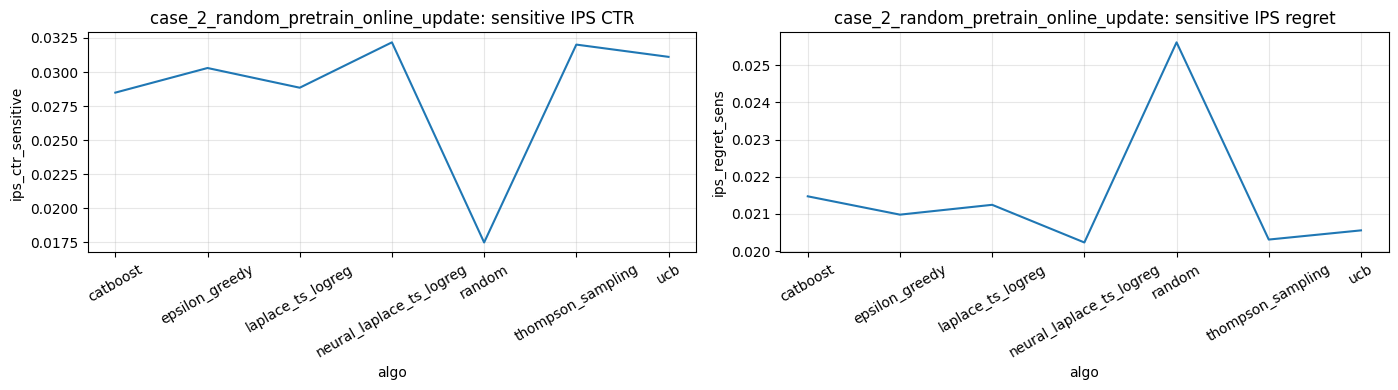

In [15]:
if set(sensitive_cols).issubset(metrics_df.columns):
    sensitive_plot_df = metrics_df[sensitive_cols].copy()
    sensitive_plot_df = sensitive_plot_df[sensitive_plot_df['sensitive_impressions'] > 0]

    if sensitive_plot_df.empty:
        print('Нет данных для sensitive IPS графика (sensitive_impressions == 0).')
    else:
        for scenario_name, part in sensitive_plot_df.groupby('scenario'):
            fig, axes = plt.subplots(1, 2, figsize=(14, 4))
            part = part.sort_values('algo')

            axes[0].plot(part['algo'], part['ips_ctr_sensitive'], label=algo)
            axes[0].set_title(f'{scenario_name}: sensitive IPS CTR')
            axes[0].set_xlabel('algo')
            axes[0].set_ylabel('ips_ctr_sensitive')
            axes[0].tick_params(axis='x', rotation=30)

            axes[1].plot(part['algo'], part['ips_regret_sens'], label=algo)
            axes[1].set_title(f'{scenario_name}: sensitive IPS regret')
            axes[1].set_xlabel('algo')
            axes[1].set_ylabel('ips_regret_sens')
            axes[1].tick_params(axis='x', rotation=30)

            for ax in axes:
                ax.grid(True, alpha=0.3)

            fig.tight_layout()
            plt.show()
else:
    print('Sensitive IPS колонки отсутствуют в metrics_df.')


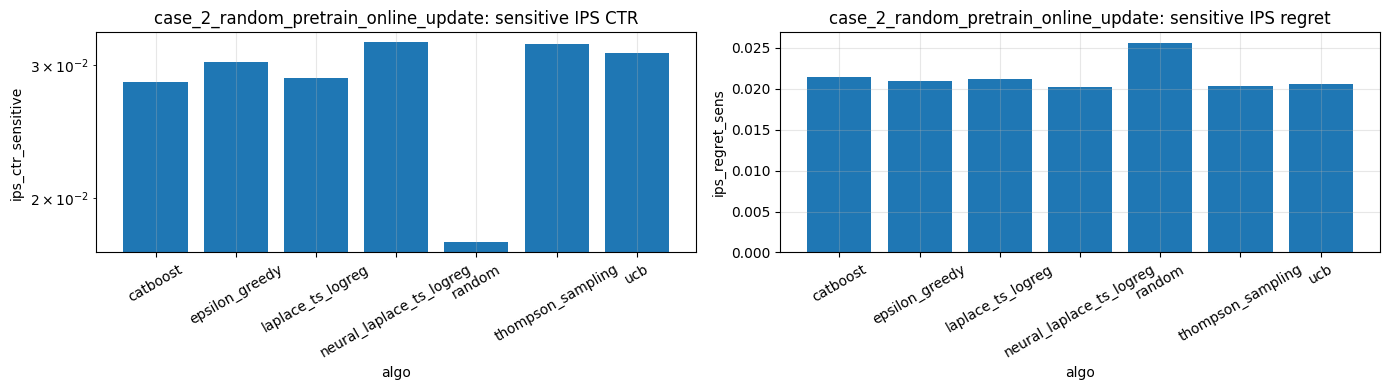

In [17]:
if set(sensitive_cols).issubset(metrics_df.columns):
    sensitive_plot_df = metrics_df[sensitive_cols].copy()
    sensitive_plot_df = sensitive_plot_df[sensitive_plot_df['sensitive_impressions'] > 0]

    if sensitive_plot_df.empty:
        print('Нет данных для sensitive IPS графика (sensitive_impressions == 0).')
    else:
        for scenario_name, part in sensitive_plot_df.groupby('scenario'):
            fig, axes = plt.subplots(1, 2, figsize=(14, 4))
            part = part.sort_values('algo')

            axes[0].bar(part['algo'], part['ips_ctr_sensitive'])
            axes[0].set_title(f'{scenario_name}: sensitive IPS CTR')
            axes[0].set_xlabel('algo')
            axes[0].set_ylabel('ips_ctr_sensitive')
            axes[0].set_yscale('log')
            axes[0].tick_params(axis='x', rotation=30)

            axes[1].bar(part['algo'], part['ips_regret_sens'])
            axes[1].set_title(f'{scenario_name}: sensitive IPS regret')
            axes[1].set_xlabel('algo')
            axes[1].set_ylabel('ips_regret_sens')
            axes[1].tick_params(axis='x', rotation=30)

            for ax in axes:
                ax.grid(True, alpha=0.3)

            fig.tight_layout()
            plt.show()
else:
    print('Sensitive IPS колонки отсутствуют в metrics_df.')


## 7) Графики по статистикам action'ов
Показывает динамику общего числа уникальных action'ов и количества новых action'ов по дням/checkpoint'ам.

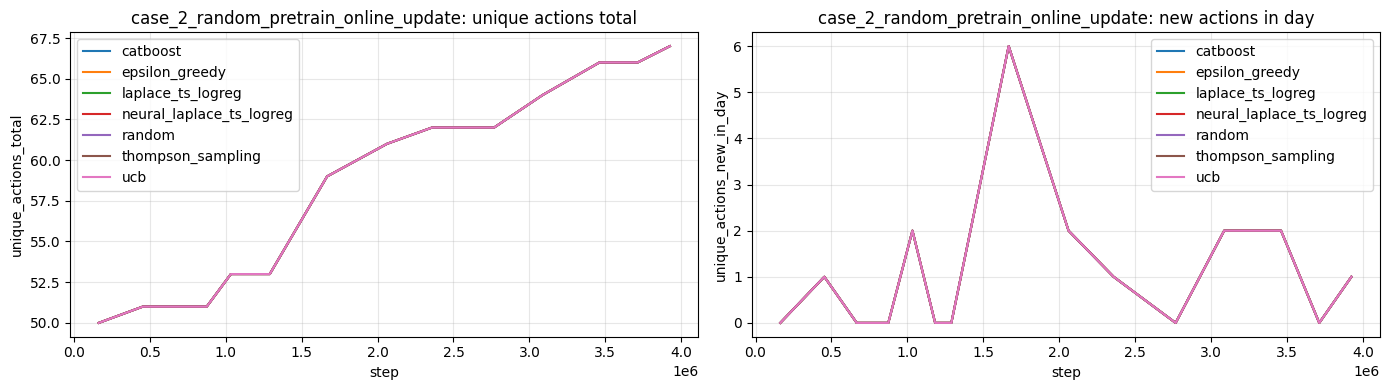

In [11]:
if not action_stats_df.empty:
    for scenario_name, part in action_stats_df.groupby('scenario'):
        fig, axes = plt.subplots(1, 2, figsize=(14, 4))

        for algo, algo_df in part.groupby('algo'):
            algo_df = algo_df.sort_values('step')
            axes[0].plot(algo_df['step'], algo_df['unique_actions_total'], label=algo)
            axes[1].plot(algo_df['step'], algo_df['unique_actions_new_in_day'], label=algo)

        axes[0].set_title(f"{scenario_name}: unique actions total")
        axes[0].set_xlabel('step')
        axes[0].set_ylabel('unique_actions_total')

        axes[1].set_title(f"{scenario_name}: new actions in day")
        axes[1].set_xlabel('step')
        axes[1].set_ylabel('unique_actions_new_in_day')

        for ax in axes:
            ax.grid(True, alpha=0.3)
            ax.legend()

        fig.tight_layout()
        plt.show()
else:
    print('action_stats_df is empty.')


## 8) Распределение показов по action и дням


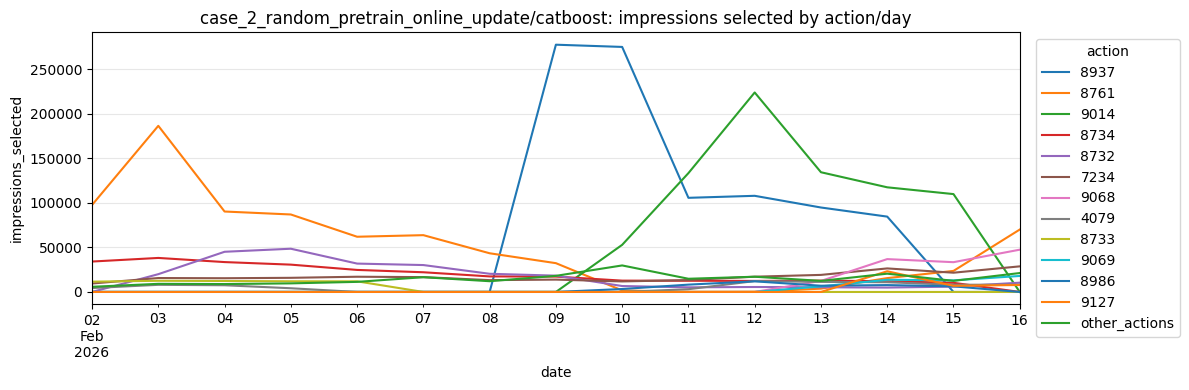

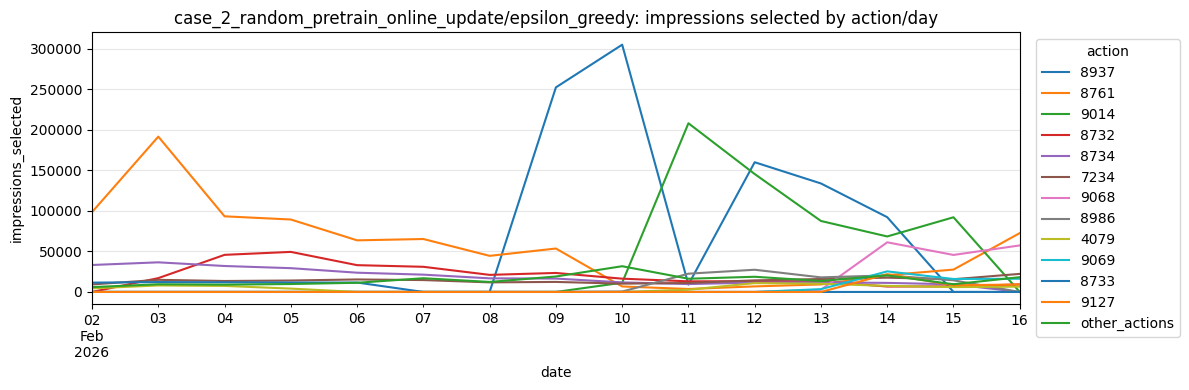

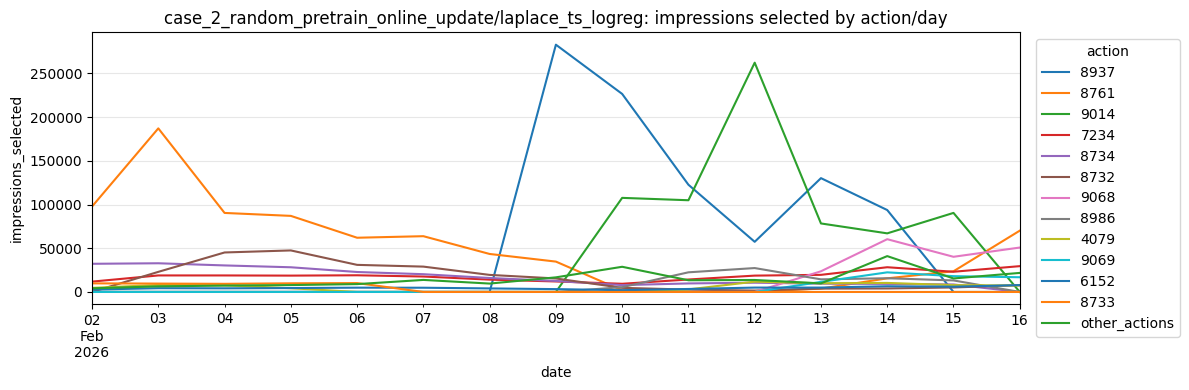

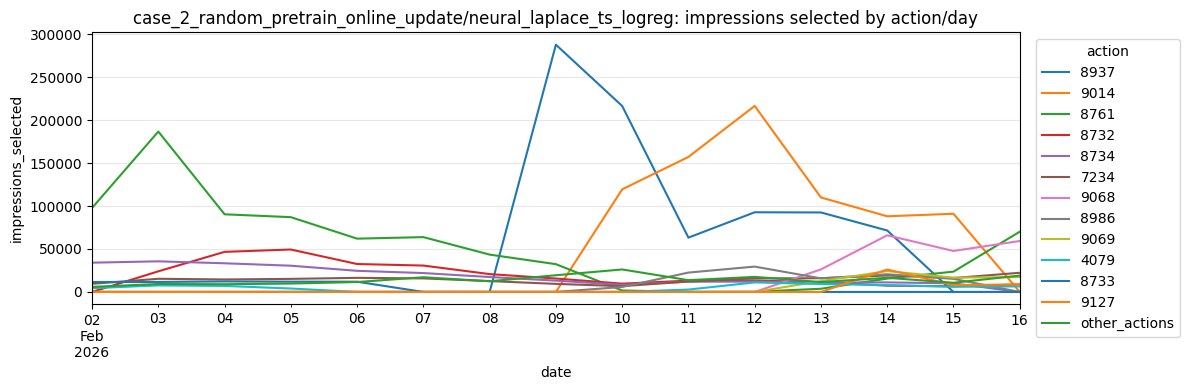

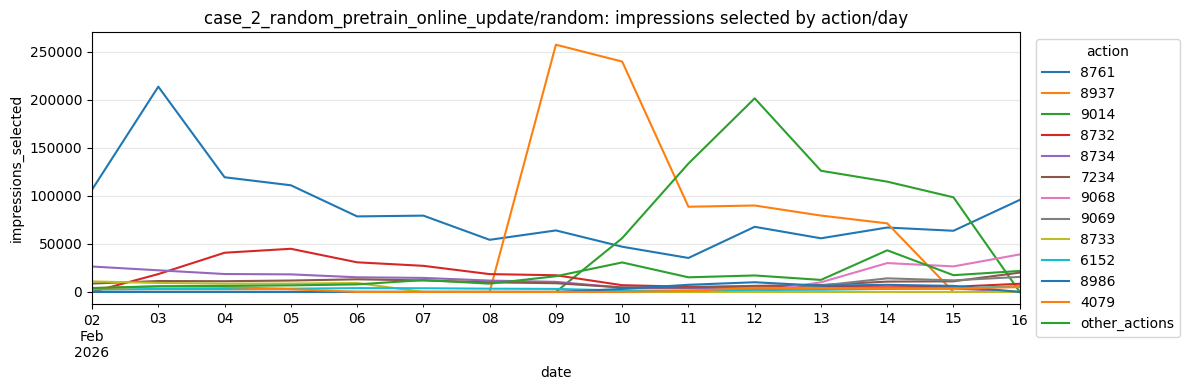

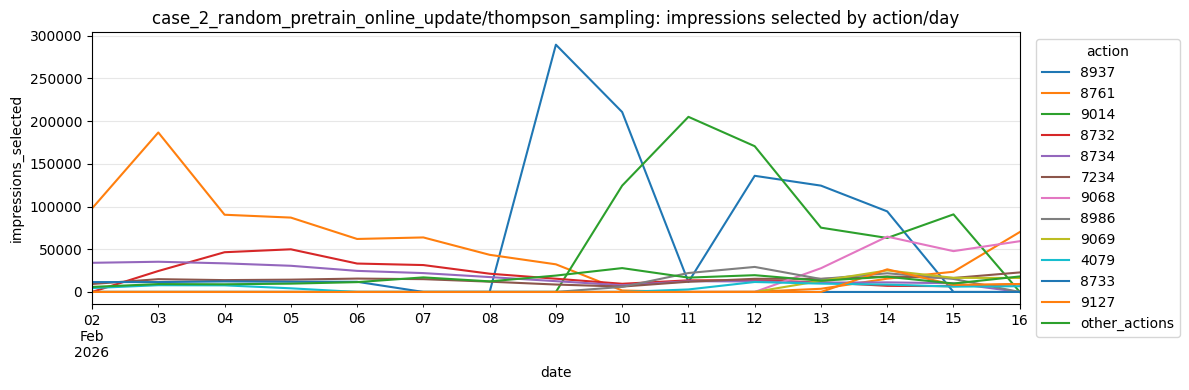

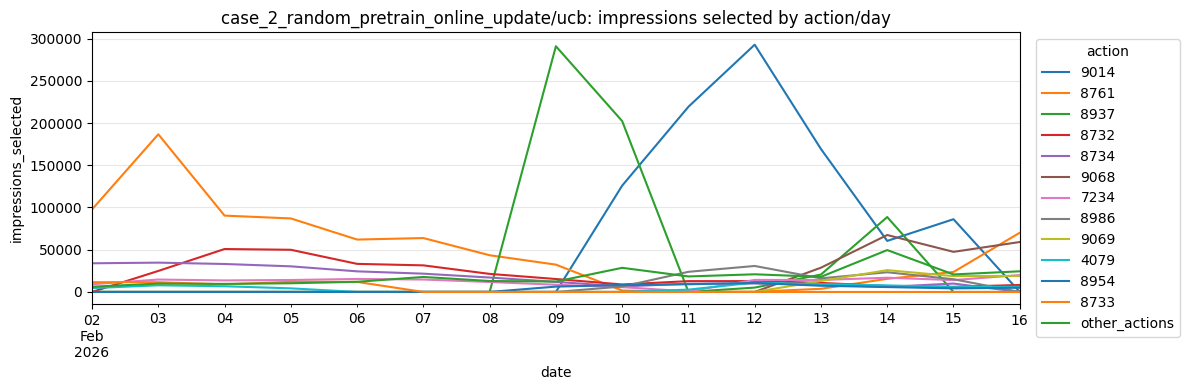

In [12]:
if not action_daily_stats_df.empty:
    top_actions_n = 12

    for scenario_name, part in action_daily_stats_df.groupby('scenario'):
        for algo_name, algo_df in part.groupby('algo'):
            pivot_cnt = algo_df.pivot_table(index='date', columns='action', values='impressions_selected', aggfunc='sum').fillna(0)

            if pivot_cnt.shape[1] > top_actions_n:
                action_totals = pivot_cnt.sum(axis=0).sort_values(ascending=False)
                top_actions = action_totals.head(top_actions_n).index
                other_actions = [a for a in pivot_cnt.columns if a not in top_actions]

                plot_df = pivot_cnt.loc[:, top_actions].copy()
                if other_actions:
                    plot_df['other_actions'] = pivot_cnt.loc[:, other_actions].sum(axis=1)
            else:
                plot_df = pivot_cnt.copy()

            fig, ax = plt.subplots(figsize=(12, 4))
            plot_df.sort_index().plot(ax=ax)
            ax.set_title(f'{scenario_name}/{algo_name}: impressions selected by action/day')
            ax.set_xlabel('date')
            ax.set_ylabel('impressions_selected')
            ax.grid(True, alpha=0.3)
            ax.legend(loc='upper left', bbox_to_anchor=(1.01, 1), title='action')
            fig.tight_layout()
            plt.show()
else:
    print('action_daily_stats_df is empty.')


## 9) Сохранение артефактов

In [ ]:
OUT_DIR = ROOT / 'artifacts'
OUT_DIR.mkdir(parents=True, exist_ok=True)

metrics_path = OUT_DIR / 'metrics.csv'
history_path = OUT_DIR / 'history.csv'
action_stats_path = OUT_DIR / 'action_stats.csv'
action_daily_stats_path = OUT_DIR / 'action_daily_stats.csv'

metrics_df.to_csv(metrics_path, index=False)
history_df.to_csv(history_path, index=False)
action_stats_df.to_csv(action_stats_path, index=False)
action_daily_stats_df.to_csv(action_daily_stats_path, index=False)

print('saved metrics:', metrics_path)
print('saved history:', history_path)
print('saved action stats:', action_stats_path)
print('saved action daily stats:', action_daily_stats_path)
